# Import dependencies

In [2]:
# Import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset

In [ ]:
# Load the dataset from Mendeley
dataset = pd.read_csv("data/DrugReviews.csv")

# Exploratory Data Analysis (EDA)

In [8]:
# Inspect the dataset
display(dataset.head())
print(f"Dataset shape {dataset.shape}")

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes
0,12 Hour Nasal Decongestant Spray,For Nasal Congestion,26-Jan-21,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0
1,12 Hour Nasal Decongestant Spray,For Nasal Congestion,19-Aug-22,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0
2,12 Hour Nasal Decongestant Spray,For Nasal Congestion,28-Apr-18,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0
3,5-HTP,For Anxiety,3-May-20,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345
4,5-HTP,For Anxiety,11-Jul-19,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229


Dataset shape (392510, 9)


### Columns information

- `MedicineName` - name of the medicine
- `MedicineFor` - therapeutic apllication of the medicine
- `ReviewDate`- date when the review was posted
- `UserName` - reviewer's username
- `IntakeTime` - treatment duration
- `Reviews` - review of the medicine
- `ReviewLenght` - number of character of the review
- `Rating` - rating of the medicine given by the reviewer
- `NumberOfLikes` - number of likes the review obtained

In [9]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392510 entries, 0 to 392509
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   MedicineName   392510 non-null  object
 1   MedicineFor    392510 non-null  object
 2   ReviewDate     392510 non-null  object
 3   UserName       392454 non-null  object
 4   IntakeTime     392510 non-null  object
 5   Reviews        392510 non-null  object
 6   ReviewLength   392510 non-null  int64 
 7   Rating         392510 non-null  int64 
 8   NumberOfLikes  392510 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 27.0+ MB


In [14]:
# Check for null values
dataset.isnull().sum()

MedicineName      0
MedicineFor       0
ReviewDate        0
UserName         56
IntakeTime        0
Reviews           0
ReviewLength      0
Rating            0
NumberOfLikes     0
dtype: int64

In [15]:
# Check for duplicated entries
print(f"Duplicated entries: {int(dataset.duplicated().sum())}")

Duplicated entries: 607


In [16]:
print(f"Duplicated reviews of medicines: {dataset.duplicated(['MedicineName', 'Reviews']).sum()}")

Duplicated reviews of medicines: 5473


In [17]:
print(f"Duplicated reviews of medicines: {dataset.duplicated(['MedicineName', 'Reviews', 'Rating']).sum()}")

Duplicated reviews of medicines: 5367


In [18]:
# Inspect ReviewLenght, Rating, and NumberOfLikes ranges
dataset[['ReviewLength', 'Rating', 'NumberOfLikes']].describe().T

,count,mean,std,min,25%,50%,75%,max
ReviewLength,392510.0,336.650422,262.251652,1.0,109.0,274.0,517.0,4930.0
Rating,392510.0,6.281364,3.576652,1.0,2.0,8.0,10.0,10.0
NumberOfLikes,392510.0,26.995376,49.376236,0.0,4.0,13.0,32.0,3555.0


In [19]:
dataset[['ReviewLength', 'Rating', 'NumberOfLikes']].mode()

,ReviewLength,Rating,NumberOfLikes
0,38,10,0


In [20]:
dataset[['ReviewLength', 'Rating', 'NumberOfLikes']].skew()

ReviewLength      0.800007
Rating           -0.423498
NumberOfLikes    12.995164
dtype: float64

## Dataset analysis

- This dataset has 392510 rows corresponding to reviews and 9 columns corresponding to different features.

- Most column are of `object` type and three `ReviewLength`, `Rating`, and `NumberOfLikes` are `int64`.
- There are 56 missing values in the `UserName` column, however these are not relevant consider no relevant information in contained in this column. No other missing values were observed.
- There are 607 duplicated entries. However, if we search for duplicates unsing only the `MedicineName`and `Reviews` columns, this number increases to 5473. This indicates that the same review was posted more than once or on different websites.
- The number of characters range from 1 to 4930, being the median 274, the mean 337, and the mode 38 characters, showing a positive skew. This indicates that the bulk of the reviews have fewer characters, but there are some reviews with a high number of characters.
- The rating ranges from 1 to 10, being the median 8.0, the mean 6.3, and the mode 10, showing a negative skew. This indicates that the bulk of the reviews have higher ratings, but there are some review with low ratings.
- The number of likes the publications have ranges from 0 to 3555, being the median 13.0, the mean 27, and the mode 0, showing a strong positive skew. This This indicates that the bulk of the reviews have few or no likes, but there are some reviews with a high number of likes.

## Data cleaning and Feature Engineering

In [21]:
df = dataset.copy()
display(df.head())
print(f"Dataset shape {df.shape}")

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes
0,12 Hour Nasal Decongestant Spray,For Nasal Congestion,26-Jan-21,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0
1,12 Hour Nasal Decongestant Spray,For Nasal Congestion,19-Aug-22,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0
2,12 Hour Nasal Decongestant Spray,For Nasal Congestion,28-Apr-18,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0
3,5-HTP,For Anxiety,3-May-20,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345
4,5-HTP,For Anxiety,11-Jul-19,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229


Dataset shape (392510, 9)


In [22]:
# Drop duplicated reviews
df = df.drop_duplicates(subset=['MedicineName', 'Reviews'], ignore_index=True)
print(f"Shape after dropping duplicated reviews {df.shape}")

Shape after dropping duplicated reviews (387037, 9)


In [23]:
# Convert medicine names and medicine uses to lowercase
df['MedicineName'] = df['MedicineName'].str.lower().str.strip()
df['MedicineFor'] = df['MedicineFor'].str.lower().str.strip()
df.head()

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes
0,12 hour nasal decongestant spray,for nasal congestion,26-Jan-21,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0
1,12 hour nasal decongestant spray,for nasal congestion,19-Aug-22,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0
2,12 hour nasal decongestant spray,for nasal congestion,28-Apr-18,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0
3,5-htp,for anxiety,3-May-20,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345
4,5-htp,for anxiety,11-Jul-19,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229


In [24]:
# Remove the "for " before the condition for which the medicine is used
df['MedicineFor'] = df['MedicineFor'].str.removeprefix('for ').str.strip()
df.head()

,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes
0,12 hour nasal decongestant spray,nasal congestion,26-Jan-21,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0
1,12 hour nasal decongestant spray,nasal congestion,19-Aug-22,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0
2,12 hour nasal decongestant spray,nasal congestion,28-Apr-18,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0
3,5-htp,anxiety,3-May-20,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345
4,5-htp,anxiety,11-Jul-19,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229


In [28]:
# Check Top 20 medicine uses to see if there are different ways of describing the same use
df['MedicineFor'].value_counts().head(20)

MedicineFor
birth control                                                   26755
depression                                                      11891
anxiety                                                          9585
weight loss (obesity/overweight)                                 8145
not mentioned                                                    7532
pain                                                             6720
acne                                                             6514
insomnia                                                         6410
bipolar disorder                                                 5597
nexplanon (etonogestrel) for birth control                       4468
diabetes, type 2                                                 4440
high blood pressure                                              4368
vaginal yeast infection                                          4279
emergency contraception                                          3852
adhd    

In [30]:
# Keep only "birth control" when the entry has more information, such as "nexplanon (etonogestrel) for birth control"
mask = df['MedicineFor'].str.contains('birth control', case=False, na=False)
df.loc[mask, 'MedicineFor'] = 'birth control'

In [31]:
# Parse ReviewDate to datetime
df['ReviewDate'] = pd.to_datetime(df['ReviewDate'], dayfirst=False)

# Extract components into new columns
df['ReviewDay']   = df['ReviewDate'].dt.day
df['ReviewMonth'] = df['ReviewDate'].dt.month
df['ReviewYear']  = df['ReviewDate'].dt.year

display(df.head())
print(f"Dataset shape with parsed date {df.shape}")

/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_1515/3788442687.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['ReviewDate'] = pd.to_datetime(df['ReviewDate'], dayfirst=False)


,MedicineName,MedicineFor,ReviewDate,UserName,IntakeTime,Reviews,ReviewLength,Rating,NumberOfLikes,ReviewDay,ReviewMonth,ReviewYear
0,12 hour nasal decongestant spray,nasal congestion,2021-01-26,xano,Not Specified,This is very effective IF you can get the cove...,52,6,0,26,1,2021
1,12 hour nasal decongestant spray,nasal congestion,2022-08-19,Breat...,Taken for 1 to 2 years,Actually I use the generic brand of the 12 hou...,319,10,0,19,8,2022
2,12 hour nasal decongestant spray,nasal congestion,2018-04-28,Abe,Taken for less than 1 month,Cap took 20 minutes to open process was frustr...,373,1,0,28,4,2018
3,5-htp,anxiety,2020-05-03,Andres,Taken for less than 1 month,Hi everyone\r\n'10 / 105-HTPFor Anxiety23129-O...,623,10,345,3,5,2020
4,5-htp,anxiety,2019-07-11,Shawn,Not Specified,Took SSRI (Prozac) for Anxiety/Depression for ...,156,9,229,11,7,2019


Dataset shape with parsed date (387037, 12)


In [32]:
df[['ReviewDay', 'ReviewMonth', 'ReviewYear']].nunique()

ReviewDay      31
ReviewMonth    12
ReviewYear     16
dtype: int64

In [33]:
df[['ReviewDay', 'ReviewMonth', 'ReviewYear']].describe().T

,count,mean,std,min,25%,50%,75%,max
ReviewDay,387037.0,15.671693,8.774547,1.0,8.0,16.0,23.0,31.0
ReviewMonth,387037.0,6.405881,3.443735,1.0,3.0,6.0,9.0,12.0
ReviewYear,387037.0,2016.899506,3.754157,2008.0,2015.0,2017.0,2020.0,2023.0


The date parsing was validated by assessing the range and the number of unique values in each column.

## Visualizations

In [34]:
# Get top 10 medicines by count
top10_medicines  = df['MedicineName'].value_counts().head(10)

# Get top 10 medicine uses by count
top10_conditions = df['MedicineFor'].loc[df['MedicineFor'] != 'not mentioned'].value_counts().head(10)

# Get top 5 medicine uses by count and do not include not mentioned uses
top5_conditions  = df['MedicineFor'].loc[df['MedicineFor'] != 'not mentioned'].value_counts().head(5).index

In [35]:
print(f"--- Top 10 medicines---\n {top10_medicines}\n")
print(f"--- Top 10 medicine uses ---\n {top10_conditions}")

--- Top 10 medicines---
 MedicineName
levonorgestrel                        9378
ethinyl estradiol / norethindrone     7019
etonogestrel                          6097
ethinyl estradiol / norgestimate      5344
ethinyl estradiol / levonorgestrel    4727
nexplanon                             4496
sertraline                            3939
miconazole topical                    3838
escitalopram                          3440
drospirenone / ethinyl estradiol      2605
Name: count, dtype: int64

--- Top 10 medicine uses ---
 MedicineFor
birth control                       59828
depression                          11891
anxiety                              9585
weight loss (obesity/overweight)     8145
pain                                 6720
acne                                 6514
insomnia                             6410
bipolar disorder                     5597
diabetes, type 2                     4440
high blood pressure                  4368
Name: count, dtype: int64


/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_1515/2210756927.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_1515/2210756927.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


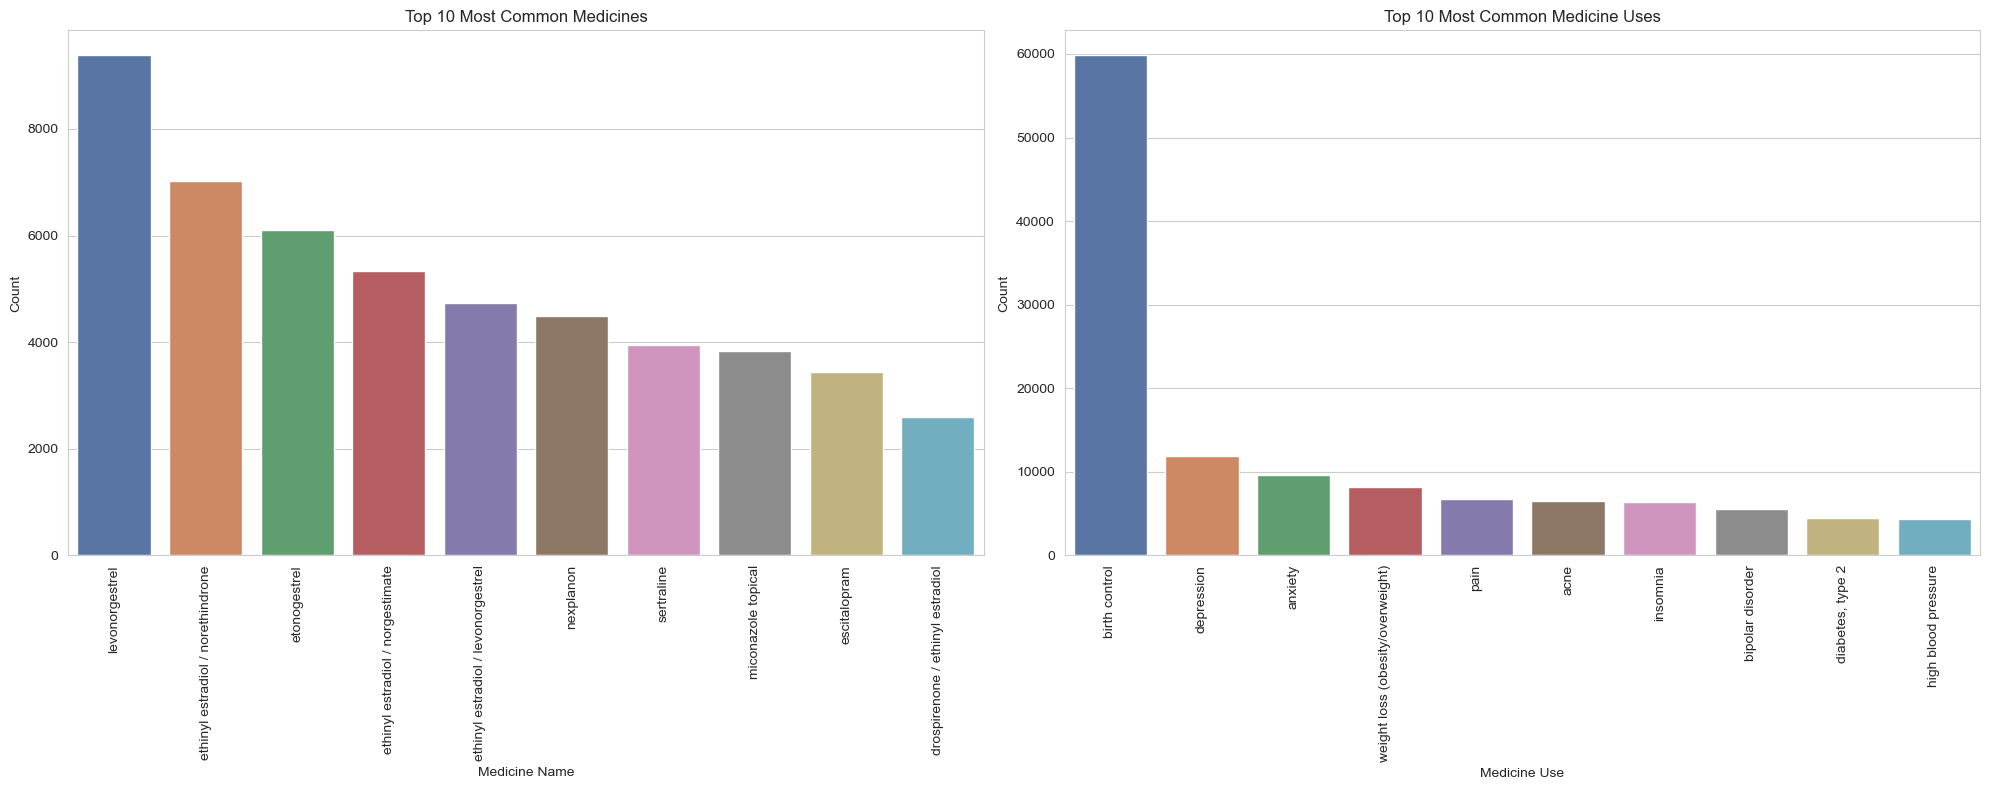

In [48]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Top 10 most common medicines
sns.barplot(
    x=top10_medicines.index,
    y=top10_medicines.values,
    palette='deep',
    ax=axes[0]
)
axes[0].set_title('Top 10 Most Common Medicines')
axes[0].set_xlabel('Medicine Name')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=90)

# Top 10 most common medicine uses
sns.barplot(
    x=top10_conditions.index,
    y=top10_conditions.values,
    palette='deep',
    ax=axes[1]
)
axes[1].set_title('Top 10 Most Common Medicine Uses')
axes[1].set_xlabel('Medicine Use')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.savefig('data/figures/top10_med_cond.png')
plt.show()

**Most common medicines and medicine uses**

- The most reviewed medicine is levonorgestrel, followed by the combination of ethinyl estradiol with norethinndrone and etonogestrel. It's clear that the most reviwed medicines are used for birth control (7 out of the top 10 most reviewed medicines).

- This is also observed in the top 10 most common medicine uses, where birth control medicines have a significantly higher number of reviews when compared with the remaining uses. Birth control usage if followed by depression and anxiety categories.

In [47]:
# Filter dataset to include only top 5 conditions
filtered_df = df[df['MedicineFor'].isin(top5_conditions)]


# Group by condition and medicine
medicine_condition_counts = (
    filtered_df
    .groupby(['MedicineFor', 'MedicineName'])
    .size()
    .reset_index(name='count')
)
# Keep top 5 medicines of each use
top_medicines_per_condition = (
    medicine_condition_counts
    .sort_values(['MedicineFor', 'count'], ascending=[True, False])
    .groupby('MedicineFor')
    .head(5)
)

top_medicines_per_condition = top_medicines_per_condition.reset_index(drop=True)
top_medicines_per_condition

,MedicineFor,MedicineName,count
0,anxiety,lexapro,866
1,anxiety,hydroxyzine,579
2,anxiety,escitalopram,527
3,anxiety,xanax,520
4,anxiety,buspirone,512
5,birth control,ethinyl estradiol / norethindrone,6223
6,birth control,etonogestrel,6056
7,birth control,levonorgestrel,5219
8,birth control,nexplanon,4474
9,birth control,ethinyl estradiol / levonorgestrel,4115


In [ ]:
#Order by the count of medicine uses
top_medicines_per_condition['MedicineFor'] = pd.Categorical(
    top_medicines_per_condition['MedicineFor'],
    categories=top5_conditions,
    ordered=True
)

top_medicines_per_condition = top_medicines_per_condition.sort_values('MedicineFor')
top_medicines_per_condition

,MedicineFor,MedicineName,count
5,birth control,ethinyl estradiol / norethindrone,6223
6,birth control,etonogestrel,6056
7,birth control,levonorgestrel,5219
8,birth control,nexplanon,4474
9,birth control,ethinyl estradiol / levonorgestrel,4115
12,depression,zoloft,575
14,depression,cymbalta,566
13,depression,lexapro,570
11,depression,sertraline,575
10,depression,pristiq,731


/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_1515/3954904547.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset = top_medicines_per_condition.groupby('MedicineFor').nth(i)


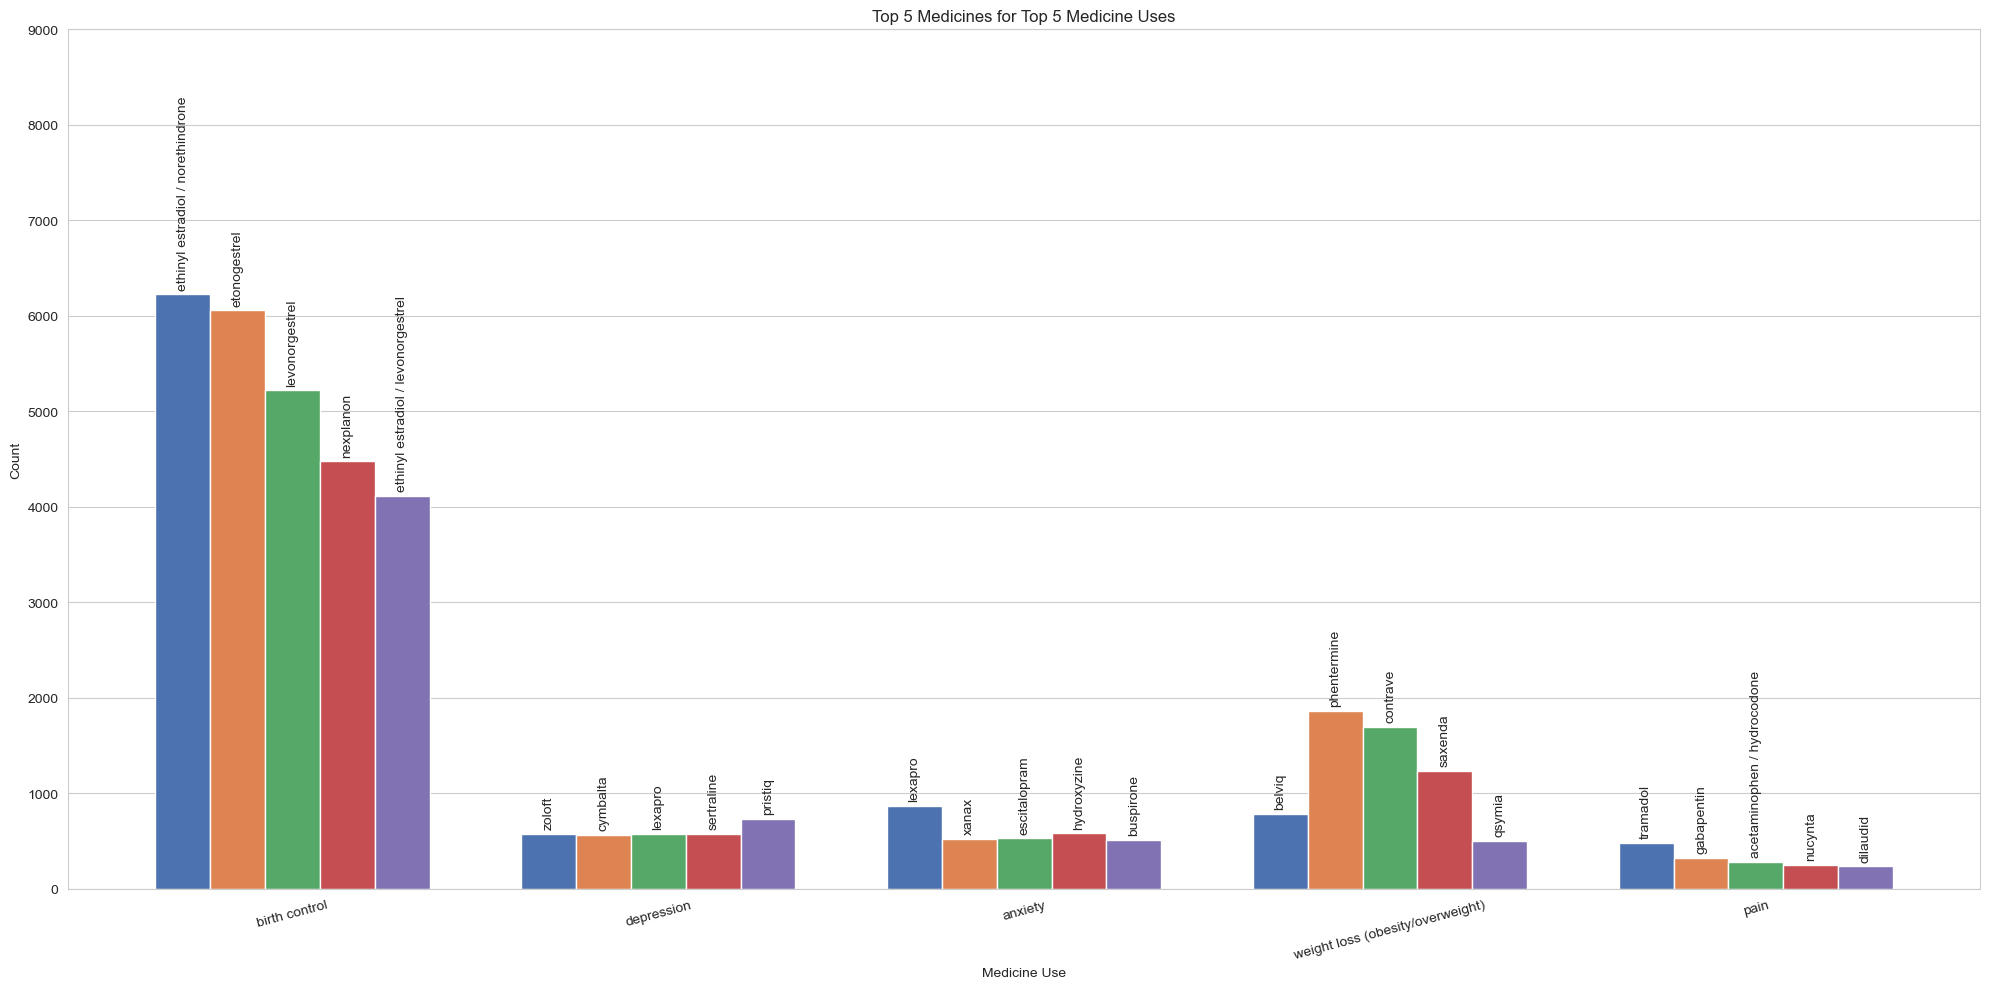

In [71]:
sns.set_style("whitegrid")
sns.set_palette('deep')

# Create figure
plt.figure(figsize=(20,10))

# Unique categories
categories = top_medicines_per_condition['MedicineFor'].unique()

# Number of groups
n_groups = len(categories)

# Number of bars per group
n_bars = 5

# X positions for groups
x = np.arange(n_groups)

# Width of each bar
width = 0.15

# Create bars
for i in range(n_bars):

    # Get ith medicine from each category
    subset = top_medicines_per_condition.groupby('MedicineFor').nth(i)

    # Bar positions
    positions = x + (i * width)

    # Draw bars
    bars = plt.bar(
        positions,
        subset['count'],
        width=width,
    )

    # Add MedicineName labels above bars
    for j, bar in enumerate(bars):

        height = bar.get_height()

        medicine_name = subset['MedicineName'].iloc[j]

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 50,
            medicine_name,
            ha='center',
            va='bottom',
            rotation=90,
            fontsize=10
        )

# Center x-axis labels
plt.xticks(
    x + width*2,
    categories,
    rotation=15
)

# Labels
plt.xlabel('Medicine Use')
plt.ylabel('Count')

# Title
plt.title('Top 5 Medicines for Top 5 Medicine Uses')

# Layout
plt.ylim(0, 9000)
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('data/figures/top5_med_top5_cond.png')
plt.show()

**Most common medicines per medicine uses**

- Birth control medicines clearly dominate the number of reviews. 

- Even though some of the top 5 medicines used for weight loss have a higher number of reviews than the top 5 medicines used for depression and anxiety, these latter categories have a higher total number of reviews, indicating a larger number os medicines used for these conditions.

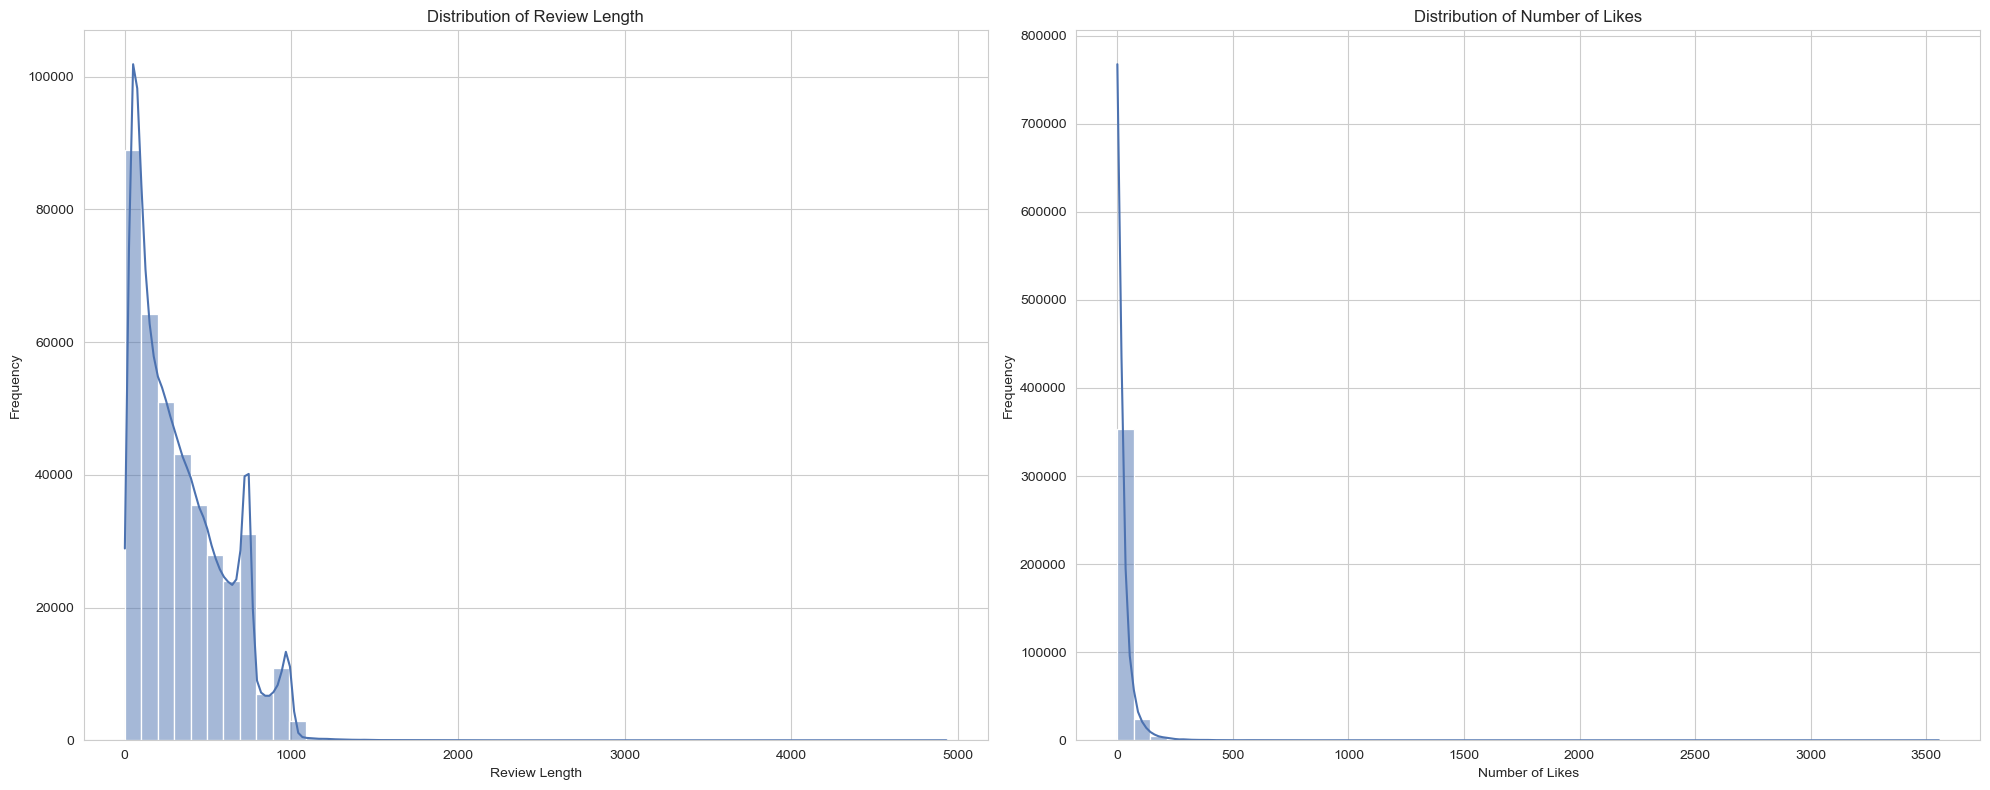

In [74]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Distribution of review lenght
sns.histplot(
    df['ReviewLength'],
    bins=50,
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Distribution of Review Length')
axes[0].set_xlabel('Review Length')
axes[0].set_ylabel('Frequency')

# Distribution of number of likes
sns.histplot(
    df['NumberOfLikes'],
    bins=50,
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Distribution of Number of Likes')
axes[1].set_xlabel('Number of Likes')
axes[1].set_ylabel('Frequency')

# Show graph
plt.tight_layout()
plt.savefig('data/figures/revlen_numlikes_distribution.png')
plt.show()

**Lenght of reviews**

- Most reviews have 800 or less characters, with reviews with less than 100 characters being the most frequent.

- There are some reviews with a high number of characters.

- As previsouly descrived, there is a positive skew in this distribution.

**Number of likes**

- Most reviews have less than 50 likes.

- There are some reviews with a high number of likes.

- As previsouly descrived, there is a marked positive skew in this distribution.

/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_1515/188273735.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


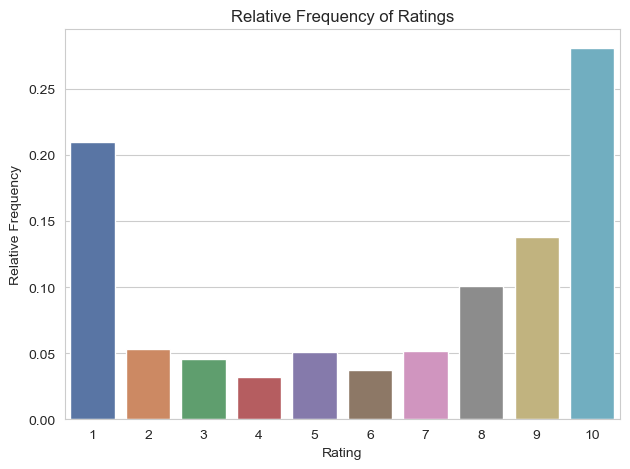

In [77]:
sns.set_style("whitegrid")

figsize=(16, 8)

# Relative frequency of ratings
rating_relative_freq = (
    df['Rating']
    .value_counts(normalize=True)
    .sort_index()
)

sns.barplot(
    x=rating_relative_freq.index,
    y=rating_relative_freq.values,
    palette='deep'
)
plt.title('Relative Frequency of Ratings')
plt.xlabel('Rating')
plt.ylabel('Relative Frequency')

# Show graph
plt.tight_layout()
plt.savefig('data/figures/ratings_rel_freq.png')
plt.show()

**Ratings**

- 10 is the most frequent medicine rating, followed by the rating of 1, 9, and 8.

- Positive ratings (≥ 7) are more common than negative ratings (≤ 4). Neutral ratings (5-6) are the least common. This shows a class imbalance in this dataset.

/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_1515/371556004.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_1515/371556004.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/ns/tz5d_bp51j59j7fmbrqg1d1h0000gn/T/ipykernel_1515/371556004.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


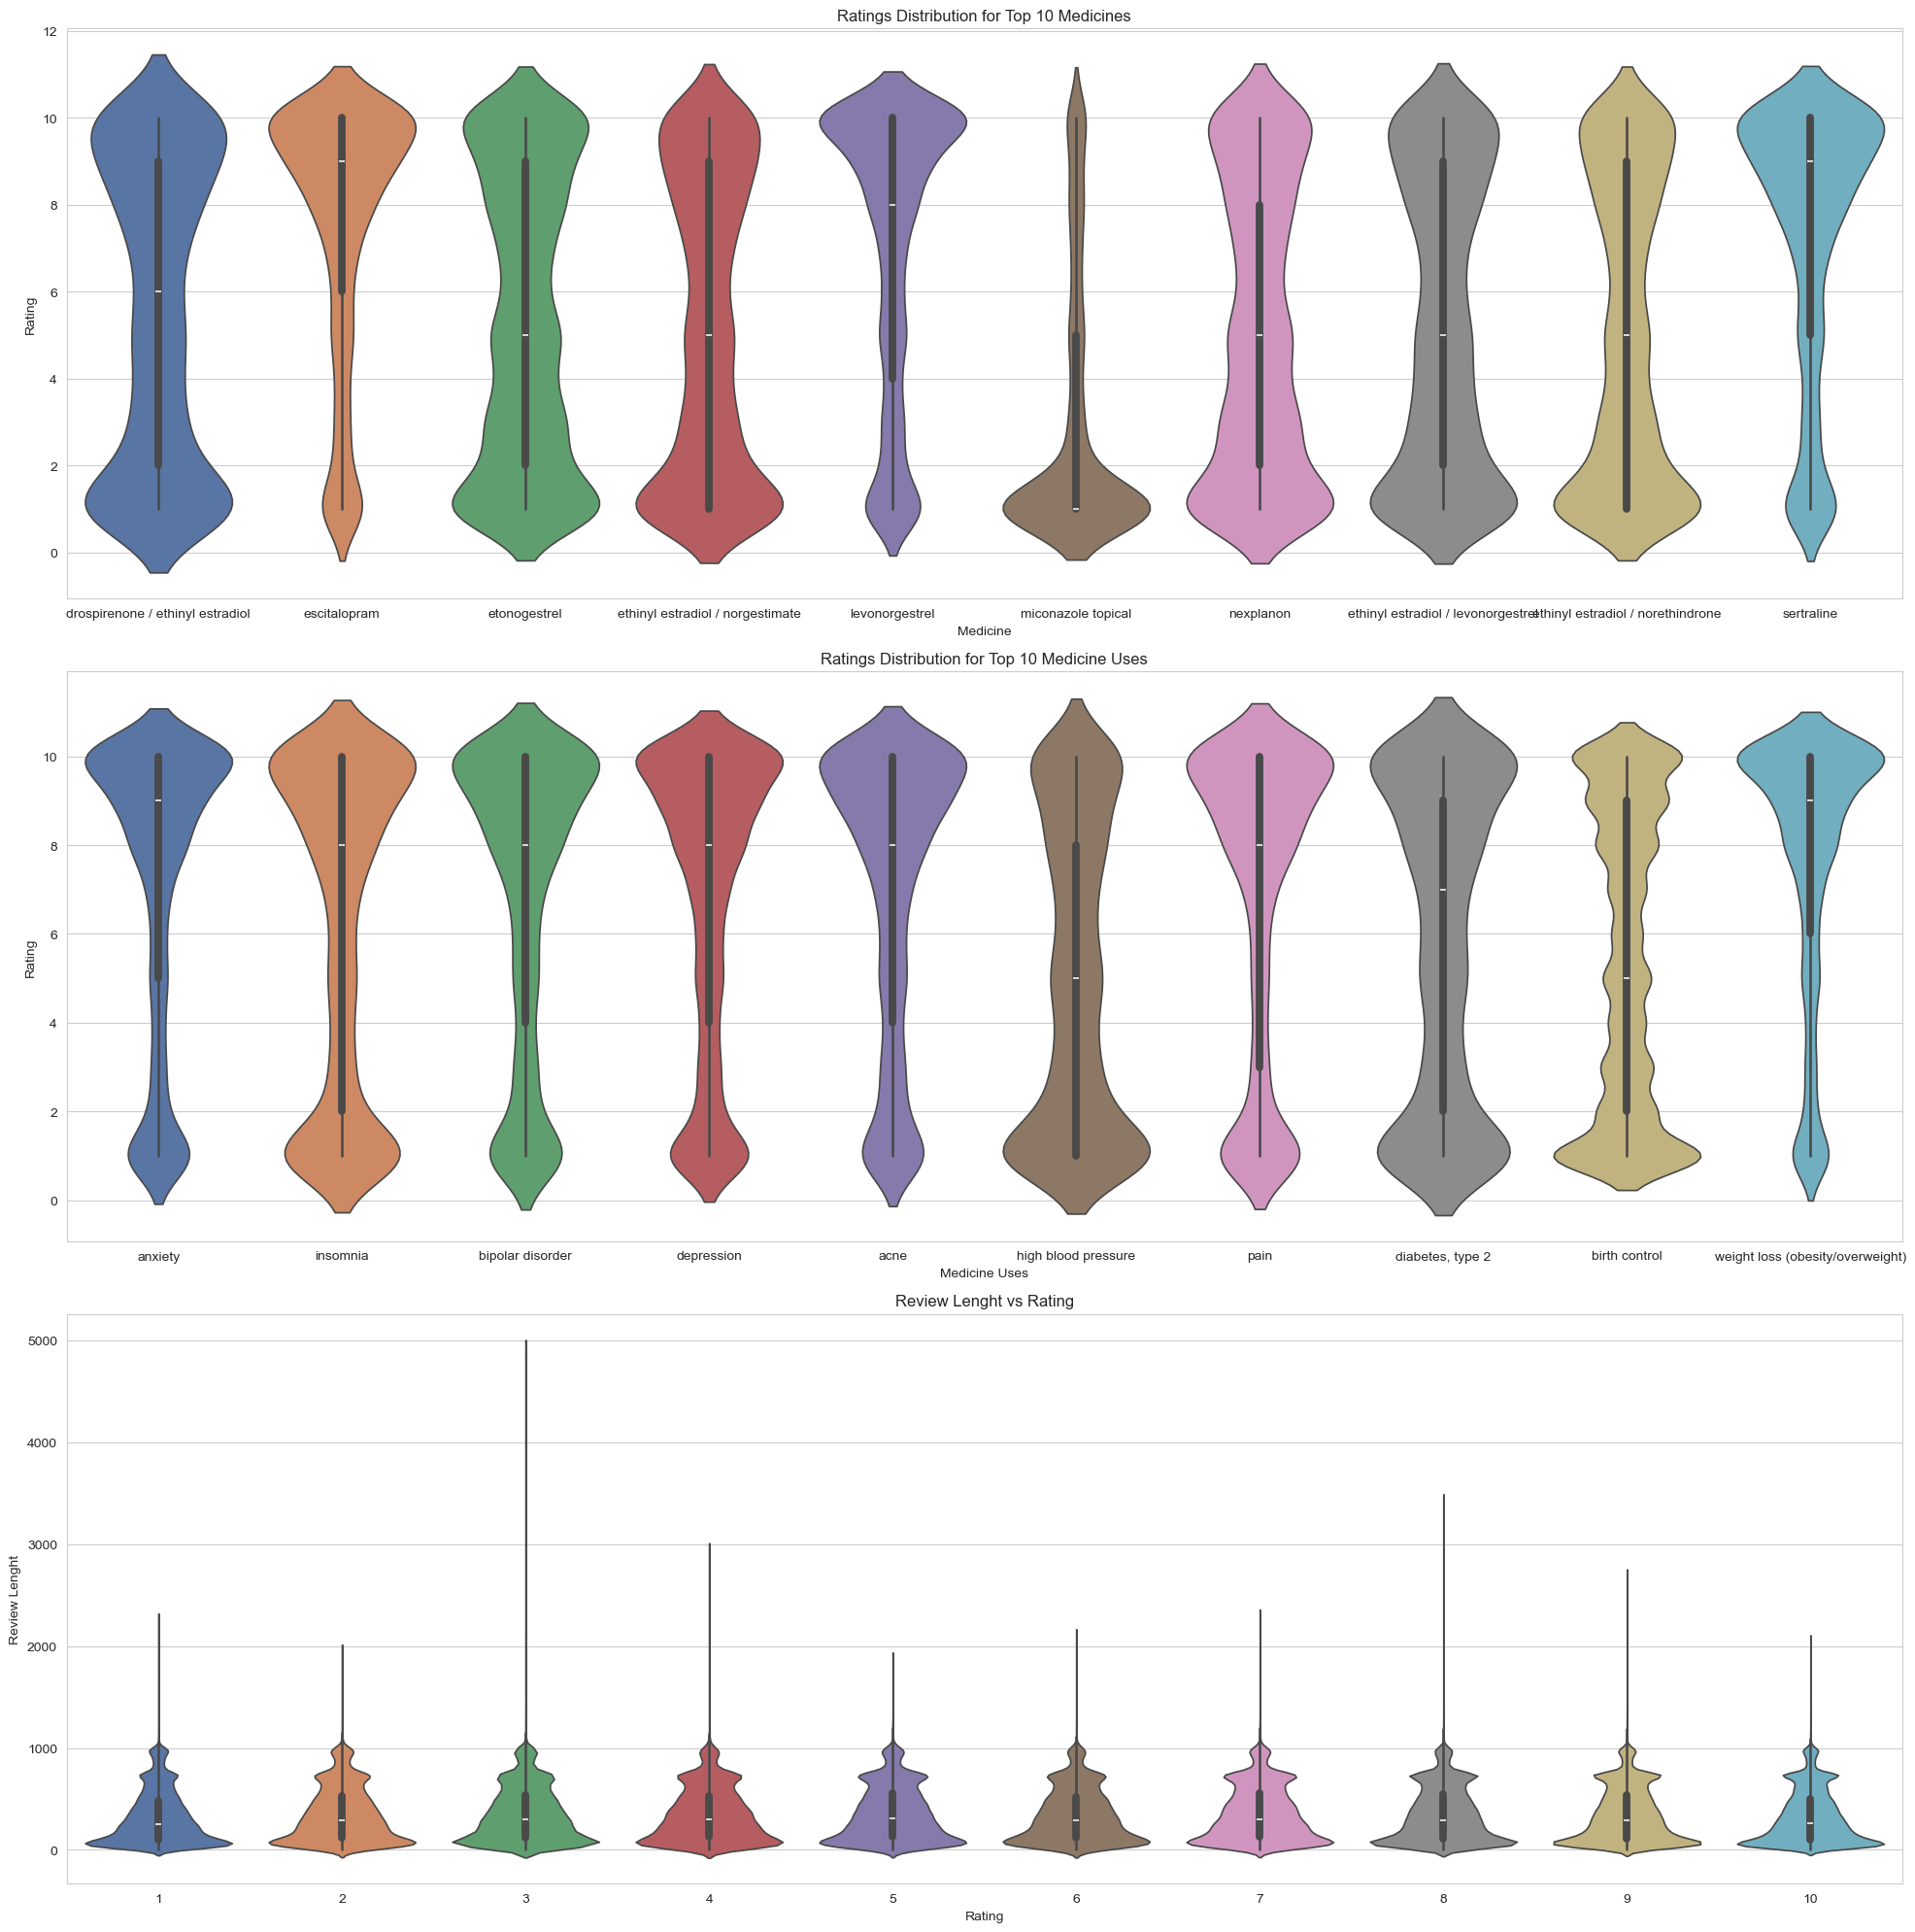

In [79]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(20, 20))

# Top 10 medicines vs ratings
sns.violinplot(
    x="MedicineName",
    y="Rating",
    data=df[df['MedicineName'].isin(top10_medicines.index)],
    palette='deep',
    ax=axes[0]
)
axes[0].set_title('Ratings Distribution for Top 10 Medicines')
axes[0].set_xlabel('Medicine')
axes[0].set_ylabel('Rating')


# Top 10 medicine uses vs ratings
sns.violinplot(
    x="MedicineFor",
    y="Rating",
    data=df[df['MedicineFor'].isin(top10_conditions.index)],
    palette='deep',
    ax=axes[1]
)
axes[1].set_title('Ratings Distribution for Top 10 Medicine Uses')
axes[1].set_xlabel('Medicine Uses')
axes[1].set_ylabel('Rating')

# Review lenght vs rating
sns.violinplot(
    x="Rating",
    y="ReviewLength",
    data=df,
    palette='deep',
    ax=axes[2]
)
axes[2].set_title('Review Lenght vs Rating')
axes[2].set_xlabel('Rating')
axes[2].set_ylabel('Review Lenght')

# Show graph
plt.tight_layout()
plt.savefig('data/figures/violin_plots.png')

plt.show()

**Rating distribution of top 10 medicines**

- Most top 10 medicines have a bimodal distribution of ratings, with larger distribution both at the top and bottom, indicating the majority of revews are either extremely positive or extremely negative.

- Some medicines, such as escitalopram and sertraline have a larger distribution at higher ratings, whereas miconazole shows a larger distribution on the lower ratings, indicating a majority of positive or negative sentiments, respectively, towards each drug.

**Rating distribution of top 10 medicine uses**

- Most top 10 medicine uses have a bimodal distribution of ratings, with larger distribution both at the top and bottom, indicating the majority of revews are either extremely positive or extremely negative. However, most have a larger distribution at higher ratings, showing a tendendcy for positive sentiments towards these categories.

**Rating distribution of top 10 medicine uses**

- The distribution of review lenght for each rating present similar distributions, not showing a pattern betweeen these two features.

- All ratings have outliers with higher characters.

In [81]:
# Export the csv file
df.to_csv("data/drug-reviews-eda.csv", index=False)